In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pyomo.environ import *


In [2]:
rtm_full = pd.read_excel("rtm_2025.xlsx")

In [3]:
rtm = rtm_full.copy()
rtm["Delivery Hour"] = rtm["Delivery Hour"] - 1
rtm["Time"] = pd.to_datetime(rtm["Delivery Date"] + " " + rtm["Delivery Hour"].astype(str) + ":00")
rtm = rtm[
    (rtm["Settlement Point Name"] == "LZ_HOUSTON") &
    (rtm["Settlement Point Type"] == "LZ") &
    (rtm["Time"] < pd.Timestamp("2025-01-08 00:00:00"))
]

rtm = rtm.groupby(["Time"])["Settlement Point Price"].mean().reset_index()
rtm


,Time,Settlement Point Price
0,2025-01-01 00:00:00,18.0775
1,2025-01-01 01:00:00,17.6875
2,2025-01-01 02:00:00,17.0950
3,2025-01-01 03:00:00,16.9800
4,2025-01-01 04:00:00,18.5475
...,...,...
163,2025-01-07 19:00:00,31.7375
164,2025-01-07 20:00:00,31.7350
165,2025-01-07 21:00:00,29.6950
166,2025-01-07 22:00:00,27.2175


In [4]:
load_list = []
for i in range(1,8):
    load_i = pd.read_csv(f"load_01_0{i}_2025.csv")
    load_list.append(load_i)
load = pd.concat(load_list)
load["HourEnding"] = load["HourEnding"].str.split(":").str[0].astype(int) - 1
load["Time"] = pd.to_datetime(load["OperDay"]) + pd.to_timedelta(load["HourEnding"], unit="h")
load = load[["Time", "HOUSTON"]]
load

,Time,HOUSTON
0,2025-01-01 00:00:00,9880.83
1,2025-01-01 01:00:00,9767.50
2,2025-01-01 02:00:00,9785.93
3,2025-01-01 03:00:00,9816.46
4,2025-01-01 04:00:00,9643.36
...,...,...
19,2025-01-07 19:00:00,13740.44
20,2025-01-07 20:00:00,13649.31
21,2025-01-07 21:00:00,13364.61
22,2025-01-07 22:00:00,12902.05


In [5]:
houston = pd.merge(rtm, load, on="Time")
houston.columns = ["Time", "Price", "Load"]
houston

,Time,Price,Load
0,2025-01-01 00:00:00,18.0775,9880.83
1,2025-01-01 01:00:00,17.6875,9767.50
2,2025-01-01 02:00:00,17.0950,9785.93
3,2025-01-01 03:00:00,16.9800,9816.46
4,2025-01-01 04:00:00,18.5475,9643.36
...,...,...,...
163,2025-01-07 19:00:00,31.7375,13740.44
164,2025-01-07 20:00:00,31.7350,13649.31
165,2025-01-07 21:00:00,29.6950,13364.61
166,2025-01-07 22:00:00,27.2175,12902.05


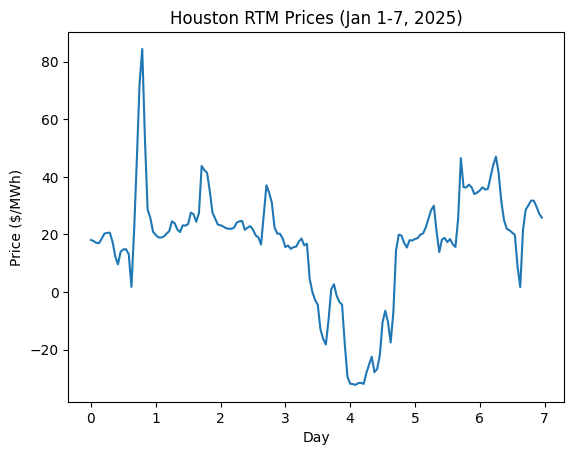

In [6]:

plt.plot(houston["Time"], houston["Price"])
daily_ticks = houston["Time"].dt.ceil('D').drop_duplicates()
plt.title("Houston RTM Prices (Jan 1-7, 2025)")
plt.ylabel("Price ($/MWh)")
plt.xlabel("Day")
plt.xticks(daily_ticks, daily_ticks.dt.day - 1);

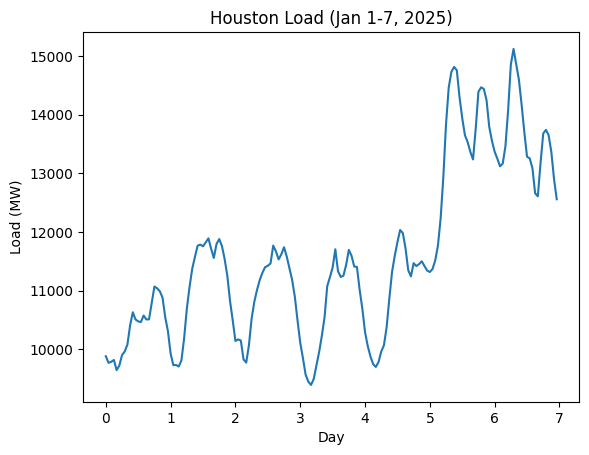

In [7]:
plt.plot(houston["Time"], houston["Load"])
plt.title("Houston Load (Jan 1-7, 2025)")
plt.ylabel("Load (MW)")
plt.xlabel("Day")
plt.xticks(daily_ticks, daily_ticks.dt.day - 1);

In [8]:
# Initialize model
am = AbstractModel()

# Sets
am.T = Set()

# Parameters
am.price = Param(am.T)
am.demand = Param(am.T)   
am.charge_limit = Param()
am.discharge_limit = Param()
am.soc_max = Param()
am.soc_min = Param()
am.charge_eff = Param()
am.discharge_eff = Param()

# Variables
am.charge = Var(am.T, within=NonNegativeReals)
am.discharge = Var(am.T, within=NonNegativeReals)
am.soc = Var(am.T, within=NonNegativeReals)
am.grid_purchase = Var(am.T, within=NonNegativeReals)
am.grid_sale = Var(am.T, within=NonNegativeReals)
am.is_charging = Var(am.T, within=Binary)


# Constraints
def soc_balance_rule(am, t):
    if t == am.T.first():
        return am.soc[t] == 0 + (am.charge[t] * am.charge_eff) - (am.discharge[t] / am.discharge_eff)
    else:
        return am.soc[t] == am.soc[am.T.prev(t)] + (am.charge[t] * am.charge_eff) - (am.discharge[t] / am.discharge_eff)
am.soc_balance = Constraint(am.T, rule=soc_balance_rule)

def charge_limit_rule(am, t):
    return am.charge[t] <= am.charge_limit * am.is_charging[t]
am.charge_limit_constraint = Constraint(am.T, rule=charge_limit_rule)

def discharge_limit_rule(am, t):
    return am.discharge[t] <= am.discharge_limit * (1 - am.is_charging[t])
am.discharge_limit_constraint = Constraint(am.T, rule=discharge_limit_rule)

def soc_max_rule(am, t):
    return am.soc[t] <= am.soc_max
am.soc_max_constraint = Constraint(am.T, rule=soc_max_rule)

def soc_min_rule(am, t):
    return am.soc[t] >= am.soc_min
am.soc_min_constraint = Constraint(am.T, rule=soc_min_rule)

def demand_balance_rule(am, t):
    return am.demand[t] == am.grid_purchase[t] + am.discharge[t] - am.charge[t] - am.grid_sale[t]
am.demand_balance = Constraint(am.T, rule=demand_balance_rule)


# Objective
def cost_rule(am):
    return sum(am.price[t] * (am.grid_purchase[t] - am.grid_sale[t]) for t in am.T)
am.cost = Objective(rule=cost_rule, sense=minimize)

In [10]:
# Data
data = { None: {
    'T': {None: list(range(1, 169))},
    'price': {t+1: houston.loc[t, "Price"] for t in range(168)},
    'demand': {t+1: houston.loc[t, "Load"] for t in range(168)},
    'charge_limit': {None: 10},
    'discharge_limit': {None: 10},
    'soc_max': {None: 50},
    'soc_min': {None: 5},
    'charge_eff': {None: 0.9},
    'discharge_eff': {None: 0.9},
 }
}

# Create instance
instance = am.create_instance(data)
# Solve
solver = SolverFactory('glpk')
results = solver.solve(instance)
bess_results = pd.DataFrame.from_dict(
    {t: (
        instance.charge[t](), 
        instance.discharge[t](), 
        instance.soc[t](), 
        instance.grid_purchase[t](), 
        instance.grid_sale[t]()
    ) for t in instance.T
    }, 
    orient='index', 
    columns=['Charge (MW)', 'Discharge (MW)', 'SOC (MWh)', 'Grid Purchase (MW)', 'Grid Sale (MW)'])
bess_results.index = houston["Time"]
bess_results


,Charge (MW),Discharge (MW),SOC (MWh),Grid Purchase (MW),Grid Sale (MW)
Time,,,,,
2025-01-01 00:00:00,5.555556,0.0,5.000000,9886.385556,0.0
2025-01-01 01:00:00,0.000000,0.0,5.000000,9767.500000,0.0
2025-01-01 02:00:00,0.000000,0.0,5.000000,9785.930000,0.0
2025-01-01 03:00:00,0.000000,0.0,5.000000,9816.460000,0.0
2025-01-01 04:00:00,0.000000,0.0,5.000000,9643.360000,0.0
...,...,...,...,...,...
2025-01-07 19:00:00,0.000000,10.0,27.222222,13730.440000,0.0
2025-01-07 20:00:00,0.000000,10.0,16.111111,13639.310000,0.0
2025-01-07 21:00:00,0.000000,10.0,5.000000,13354.610000,0.0


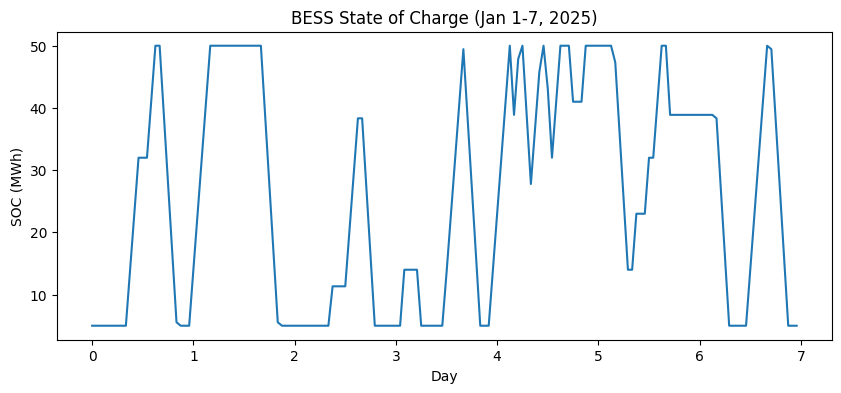

In [11]:
fig, ax = plt.subplots(figsize=(10,4))
plt.plot(houston["Time"], [instance.soc[t+1]() for t in range(168)])
plt.title("BESS State of Charge (Jan 1-7, 2025)")
plt.ylabel("SOC (MWh)")
plt.xlabel("Day")
plt.xticks(daily_ticks, daily_ticks.dt.day - 1);

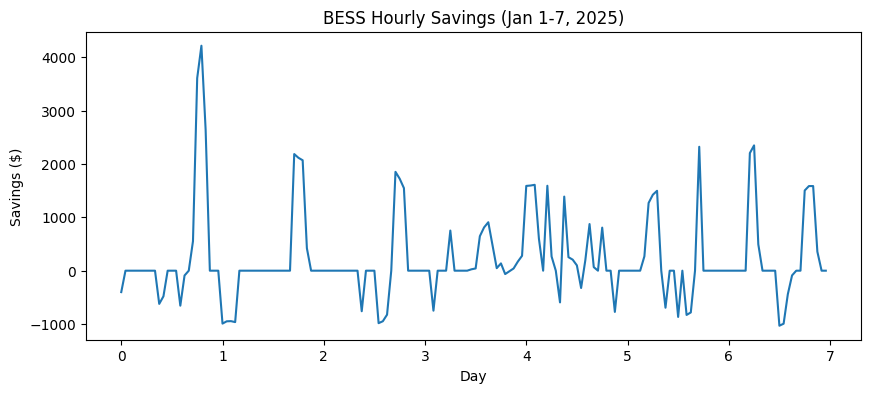

In [ ]:
cost_t = [instance.price[t+1] * (instance.grid_purchase[t+1]() - instance.grid_sale[t+1]()) for t in range(168)]

savings = houston["Load"] * houston["Price"] - cost_t
fig, ax = plt.subplots(figsize=(10,4))
plt.title("BESS Hourly Savings (Jan 1-7, 2025)")
plt.ylabel("Savings ($)")
plt.xlabel("Day")
plt.plot(houston["Time"], profit)
plt.xticks(daily_ticks, daily_ticks.dt.day - 1);



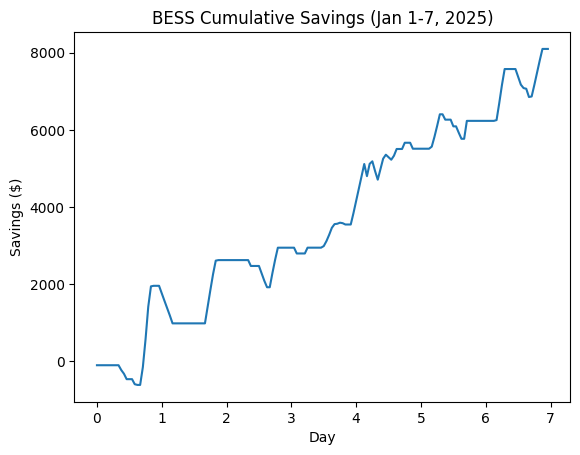

In [ ]:
plt.plot(houston["Time"], savings.cumsum())
plt.title("BESS Cumulative Savings (Jan 1-7, 2025)")
plt.ylabel("Savings ($)")
plt.xlabel("Day")
plt.xticks(daily_ticks, daily_ticks.dt.day - 1);